In [108]:
import networkx as nx
import datetime as dt
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv
from sklearn.preprocessing import MinMaxScaler

In [109]:

# works out correlation matrix for returns in window size K ending at t - so up to time t
def correlation_matrix(returns, t, K, eps=0.0, active=None):
    t = pd.to_datetime(t)
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all')
    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        window = window[active]

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]
    active_cols = window.columns.tolist()

    #scaler = MinMaxScaler(feature_range=(0, 1))
    #windowed_returns = scaler.fit_transform(windowed_returns)
    #windowed_returns = (windowed_returns - windowed_returns.min()) / (windowed_returns.max() - windowed_returns.min() + 1e-8)
    corr_matrix = window.corr().values
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)

    return corr_matrix, active_cols

# function takes in historical returns for each t with window size K 
# and computes initial node embeddings as H = US where Y = U S V^T is the SVD of the returns matrix Y

def compute_initial_node_embeddings(returns, t, K, eps=0.0, active=None):
    node_embeddings = {}
    t = pd.to_datetime(t)
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all')
    
    # Check if window is empty
    if windowed_returns.empty:
        return {}, []

    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        # Intersect active with available columns
        valid_active = [c for c in active if c in window.columns]
        if not valid_active:
            return {}, []
        window = window[valid_active]
        
    if window.shape[0] < 2 or window.shape[1] == 0: # Need at least some data
        return {}, []

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]

    active_cols = window.columns.tolist()
    if not active_cols:
        return {}, []

    U, S, Vt = np.linalg.svd(window.values, full_matrices=False)
    V = Vt.T
    H = V @ np.diag(S)
    H = H[:, :10]

    # Handle case where SVD returns fewer than 10 components
    if H.shape[1] < 10:
        padding = np.zeros((H.shape[0], 10 - H.shape[1]))
        H = np.hstack([H, padding])
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    H = scaler.fit_transform(H)

    for i, stock in enumerate(active_cols):
        node_embeddings[stock] = H[i, :] # contains only one embedding per stock at time t, embedding shape (10,)
        
    # here - store the array directly in the list to match our structure
    for stock in node_embeddings:
        node_embeddings[stock] = np.array(node_embeddings[stock])
        
    return node_embeddings, active_cols

In [110]:
# layer gives me attention weights for edges - gives A_+ and A_-
class GATLayer(torch.nn.Module):
    
    src_nodes_dim = 0  # position of source nodes in edge index
    trg_nodes_dim = 1  # position of target nodes in edge index

    nodes_dim = 0      # node dimension (the position of "N" in tensor)
    head_dim = 2       # attention head dim

    def __init__(self, num_in_features, num_out_features, num_of_heads, concat=True, activation=nn.ELU(),
                 dropout_prob=0.1, add_skip_connection=True, bias=True, log_attention_weights=False):

        super().__init__()

        self.num_of_heads = num_of_heads # number of attention heads - mine has a positive and negative head so 2
        self.num_out_features = num_out_features
        self.concat = concat  # whether we should concatenate or average the attention heads
        self.add_skip_connection = add_skip_connection

        # treat this one matrix as num_of_heads independent W matrices
        self.linear_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)

        # After we concatenate target node (node i) and source node (node j) we apply the additive scoring function
        # which gives us un-normalized score "e". we split the "a" vector - but the semantics remain the same.
        # Basically instead of doing [x, y] (concatenation, x/y are node feature vectors) and dot product with "a"
        # we instead do a dot product between x and "a_left" and y and "a_right" and we sum them up
        # these params will be updated during training (below)
        self.scoring_fn_target = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))
        self.scoring_fn_source = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))

        # Bias is definitely not crucial to GAT - feel free to experiment (I pinged the main author, Petar, on this one)
        if bias and concat:
            self.bias = nn.Parameter(torch.Tensor(num_of_heads * num_out_features))
        elif bias and not concat:
            self.bias = nn.Parameter(torch.Tensor(num_out_features))
        else:
            self.register_parameter('bias', None) # no bias

        if add_skip_connection:
            self.skip_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)
        else:
            self.register_parameter('skip_proj', None)


        self.leakyReLU = nn.LeakyReLU(0.2)  # using 0.2 as in the paper, no need to expose every setting
        self.activation = activation
        # Probably not the nicest design but I use the same module in 3 locations, before/after features projection
        # and for attention coefficients. Functionality-wise it's the same as using independent modules.
        self.dropout = nn.Dropout(p=dropout_prob)

        self.log_attention_weights = log_attention_weights  # whether we should log the attention weights
        self.attention_weights = None  # for later visualization purposes, I cache the weights here

        self.init_params()
        
    def forward(self, data):
        # Step 1: Linear Projection + regularization

        in_nodes_features, edge_index, corr = data  # unpack data - corr contains N x N correlation matrix at time t 
        num_of_nodes = in_nodes_features.shape[self.nodes_dim]
        assert edge_index.shape[0] == 2, f'Expected edge index with shape=(2,E) got {edge_index.shape}'

        # shape = (N, FIN) where N - number of nodes in the graph, FIN - number of input features per node
        # apply the dropout to all of the input node features (as mentioned in the paper)
        # can try without this part as an experiment
        in_nodes_features = self.dropout(in_nodes_features)

        # shape = (N, FIN) * (FIN, NH*FOUT) -> (N, NH, FOUT) where NH - number of heads, FOUT - num of output features
        # We project the input node features into NH independent output features (one for each attention head)
        nodes_features_proj = self.linear_proj(in_nodes_features).view(-1, self.num_of_heads, self.num_out_features)

        # can try without this
        nodes_features_proj = self.dropout(nodes_features_proj)  # in the official GAT imp they did dropout here as well

        # Step 2:edge attention calculation

        # Apply the scoring function (* represents element-wise (a.k.a. Hadamard) product)
        # shape = (N, NH, FOUT) * (1, NH, FOUT) -> (N, NH, 1) -> (N, NH) because sum squeezes the last dimension
        # Optimization note: torch.sum() is as performant as .sum() in my experiments
        scores_source = (nodes_features_proj * self.scoring_fn_source).sum(dim=-1)
        scores_target = (nodes_features_proj * self.scoring_fn_target).sum(dim=-1)

        # We simply copy (lift) the scores for source/target nodes based on the edge index. Instead of preparing all
        # the possible combinations of scores we just prepare those that will actually be used and those are defined
        # by the edge index.
        # scores shape = (E, NH), nodes_features_proj_lifted shape = (E, NH, FOUT), E - number of edges in the graph
        scores_source_lifted, scores_target_lifted, nodes_features_proj_lifted = self.lift(scores_source, scores_target, nodes_features_proj, edge_index)
        scores_per_edge = self.leakyReLU(scores_source_lifted + scores_target_lifted)
        #scores_per_edge = self.mask_function(scores_per_edge, edge_index)
        
        src = edge_index[self.src_nodes_dim]
        trg = edge_index[self.trg_nodes_dim]

        # corr is N x N, extract per-edge correlations (E,)
        corr_e = corr[src, trg] 
        # masks (E, 1) so they broadcast across heads
        mask_pos = (corr_e >= 0).float().unsqueeze(-1)
        mask_neg = (corr_e < 0).float().unsqueeze(-1)

        # two masked attentions, each normalized over the same target-neighborhood
        att_pos = self.neighborhood_aware_softmax(scores_per_edge, trg, num_of_nodes, mask_pos)
        att_neg = self.neighborhood_aware_softmax(scores_per_edge, trg, num_of_nodes, mask_neg)

        # treat them as two separate sign heads
        attentions_per_edge = torch.cat([att_pos, att_neg], dim=1)  # (E, 2*NH, 1)
        attentions_per_edge = self.dropout(attentions_per_edge)

        return attentions_per_edge
        
    def neighborhood_aware_softmax(self, scores_per_edge, trg_index, num_of_nodes, mask):
        # Calculate the numerator. Make logits <= 0 so that e^logit <= 1 (this will improve the numerical stability)
        scores_per_edge = scores_per_edge - scores_per_edge.max()
        exp_scores_per_edge = scores_per_edge.exp()  # softmax
        exp_scores_per_edge = exp_scores_per_edge * mask

        # Calculate the denominator. shape = (E, NH)
        neigborhood_aware_denominator = self.sum_edge_scores_neighborhood_aware(exp_scores_per_edge, trg_index, num_of_nodes)
        # 1e-16 is theoretically not needed but is only there for numerical stability (avoid div by 0) - due to the
        # possibility of the computer rounding a very small number all the way to 0.
        attentions_per_edge = exp_scores_per_edge / (neigborhood_aware_denominator + 1e-16)
        # shape = (E, NH) -> (E, NH, 1) so that we can do element-wise multiplication with projected node features
        return attentions_per_edge.unsqueeze(-1)

    def sum_edge_scores_neighborhood_aware(self, exp_scores_per_edge, trg_index, num_of_nodes):
        # The shape must be the same as in exp_scores_per_edge (required by scatter_add_) i.e. from E -> (E, NH)
        trg_index_broadcasted = self.explicit_broadcast(trg_index, exp_scores_per_edge)
        # shape = (N, NH), where N is the number of nodes and NH the number of attention heads
        size = list(exp_scores_per_edge.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes
        neighborhood_sums = torch.zeros(size, dtype=exp_scores_per_edge.dtype, device=exp_scores_per_edge.device)
        # position i will contain a sum of exp scores of all the nodes that point to the node i (as dictated by the
        # target index)
        neighborhood_sums.scatter_add_(self.nodes_dim, trg_index_broadcasted, exp_scores_per_edge)
        # Expand again so that we can use it as a softmax denominator. e.g. node i's sum will be copied to
        # all the locations where the source nodes pointed to i (as dictated by the target index)
        # shape = (N, NH) -> (E, NH)
        return neighborhood_sums.index_select(self.nodes_dim, trg_index)

    def aggregate_neighbors(self, nodes_features_proj_lifted_weighted, edge_index, in_nodes_features, num_of_nodes):
        size = list(nodes_features_proj_lifted_weighted.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes  # shape = (N, NH, FOUT)
        out_nodes_features = torch.zeros(size, dtype=in_nodes_features.dtype, device=in_nodes_features.device)

        # shape = (E) -> (E, NH, FOUT)
        trg_index_broadcasted = self.explicit_broadcast(edge_index[self.trg_nodes_dim], nodes_features_proj_lifted_weighted)
        # aggregation step - we accumulate projected, weighted node features for all the attention heads
        # shape = (E, NH, FOUT) -> (N, NH, FOUT)
        out_nodes_features.scatter_add_(self.nodes_dim, trg_index_broadcasted, nodes_features_proj_lifted_weighted)

        return out_nodes_features

    def lift(self, scores_source, scores_target, nodes_features_matrix_proj, edge_index):
        #Lift duplicates certain vectors depending on the edge index.
        #One of the tensor dims goes from N -> E (that's where the "lift" comes from)

        src_nodes_index = edge_index[self.src_nodes_dim]
        trg_nodes_index = edge_index[self.trg_nodes_dim]

        # Using index_select is faster than "normal" indexing (scores_source[src_nodes_index]) in PyTorch!
        scores_source = scores_source.index_select(self.nodes_dim, src_nodes_index)
        scores_target = scores_target.index_select(self.nodes_dim, trg_nodes_index)
        nodes_features_matrix_proj_lifted = nodes_features_matrix_proj.index_select(self.nodes_dim, src_nodes_index)

        return scores_source, scores_target, nodes_features_matrix_proj_lifted

    def explicit_broadcast(self, this, other):
        # Append singleton dimensions until this.dim() == other.dim()
        for _ in range(this.dim(), other.dim()):
            this = this.unsqueeze(-1)

        # Explicitly expand so that shapes are the same
        return this.expand_as(other)

    def init_params(self): # TODO: try changing initialization
        """
        The reason we're using Glorot (aka Xavier uniform) initialization is because it's a default TF initialization:
            https://stackoverflow.com/questions/37350131/what-is-the-default-variable-initializer-in-tensorflow

        The original repo was developed in TensorFlow (TF) and they used the default initialization.
        Feel free to experiment - there may be better initializations depending on your problem.

        """
        nn.init.xavier_uniform_(self.linear_proj.weight)
        nn.init.xavier_uniform_(self.scoring_fn_target)
        nn.init.xavier_uniform_(self.scoring_fn_source)

        if self.bias is not None:
            torch.nn.init.zeros_(self.bias)

    def skip_concat_bias(self, attention_coefficients, in_nodes_features, out_nodes_features):
        if self.log_attention_weights:  # potentially log for later visualization in playground.py
            self.attention_weights = attention_coefficients

        if self.add_skip_connection:  # add skip or residual connection
            if out_nodes_features.shape[-1] == in_nodes_features.shape[-1]:  # if FIN == FOUT
                # unsqueeze does this: (N, FIN) -> (N, 1, FIN), out features are (N, NH, FOUT) so 1 gets broadcast to NH
                # thus we're basically copying input vectors NH times and adding to processed vectors
                out_nodes_features += in_nodes_features.unsqueeze(1)
            else:
                # FIN != FOUT so we need to project input feature vectors into dimension that can be added to output
                # feature vectors. skip_proj adds lots of additional capacity which may cause overfitting.
                out_nodes_features += self.skip_proj(in_nodes_features).view(-1, self.num_of_heads, self.num_out_features)

        if self.concat:
            # shape = (N, NH, FOUT) -> (N, NH*FOUT)
            out_nodes_features = out_nodes_features.view(-1, self.num_of_heads * self.num_out_features)
        else:
            # shape = (N, NH, FOUT) -> (N, FOUT)
            out_nodes_features = out_nodes_features.mean(dim=self.head_dim)

        if self.bias is not None:
            out_nodes_features += self.bias

        return out_nodes_features if self.activation is None else self.activation(out_nodes_features)

In [111]:
from torch.optim import Adam

class GAT(torch.nn.Module): # gives me attention weights matrices for edges - gives A_+ and A_-

    def __init__(self, num_of_layers, num_heads_per_layer, num_features_per_layer, add_skip_connection=True, bias=True,
                 dropout=0.6, log_attention_weights=False):
        super().__init__()
        assert num_of_layers == len(num_heads_per_layer) == len(num_features_per_layer) - 1, f'Enter valid arch params.'

        num_heads_per_layer = [1] + num_heads_per_layer  # trick - so that I can nicely create GAT layers below

        gat_layers = []  # collect GAT layers
        for i in range(num_of_layers):
            layer = GATLayer(
                num_in_features=num_features_per_layer[i] * num_heads_per_layer[i],  # consequence of concatenation
                num_out_features=num_features_per_layer[i+1],
                num_of_heads=num_heads_per_layer[i+1],
                concat=True if i < num_of_layers - 1 else False,  # last GAT layer does mean avg, the others do concat
                activation=nn.ELU() if i < num_of_layers - 1 else None,  # last layer just outputs raw scores
                dropout_prob=dropout,
                add_skip_connection=add_skip_connection,
                bias=bias,
                log_attention_weights=log_attention_weights
            )
            gat_layers.append(layer)

        self.gat_net = nn.Sequential(
            *gat_layers,
        )

    # data is just a (in_nodes_features, edge_index) tuple:

    def forward(self, data):
        return self.gat_net(data)

In [112]:

class DiffusionConvLayer(nn.Module):
    
    #At each diffusion step s, compute:
    #Z_+ = sum_{s=0}^{S-1} θ_s,1 × (A_+_norm)^s × X
    #Z_- = sum_{s=0}^{S-1} θ_s,2 × (A_-_norm)^s × X
    #Output: [Z_+ || Z_-] concatenated
    
    def __init__(self, in_features, out_channels, num_diffusion_steps=1, bias=True):
    #in_features: Input feature dimension = d
    #out_channels: Number of output channels per network (Q)
    #num_diffusion_steps: Number of diffusion steps (S)
        super().__init__()
        
        self.in_features = in_features
        self.out_channels = out_channels
        self.num_diffusion_steps = num_diffusion_steps
        
        # Learnable diffusion filters: one set for positive, one for negative
        # Shape: (S, d, Q) for each
        self.theta_pos = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )
        self.theta_neg = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )
        
        if bias:
            self.bias_pos = nn.Parameter(torch.Tensor(out_channels))
            self.bias_neg = nn.Parameter(torch.Tensor(out_channels))
        else:
            self.register_parameter('bias', None)
            
        self.reset_parameters()
        
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.theta_pos)
        nn.init.xavier_uniform_(self.theta_neg)
        if self.bias_pos is not None:
            nn.init.zeros_(self.bias_pos)
        if self.bias_neg is not None:
            nn.init.zeros_(self.bias_neg)
    
    def forward(self, X_pos, X_neg, A_pos, A_neg):
        N = X_pos.shape[0] # X is N x d
        
        # Normalize adjacency matrices for random walk
        # D^(-1) × A
        D_pos = A_pos.sum(dim=1, keepdim=True) + 1e-8  # (N, 1)
        D_neg = A_neg.sum(dim=1, keepdim=True) + 1e-8
        A_t_pos_norm = A_pos / D_pos  # (N, N)
        A_neg_norm = A_neg / D_neg
        
        # Initialize outputs
        Z_pos = torch.zeros(N, self.out_channels, device=X_pos.device) # 0's
        Z_neg = torch.zeros(N, self.out_channels, device=X_neg.device)

        # Positive diffusion
        A_power = torch.eye(N, device=X_pos.device)  # A^0 = Identity matrix
        for s in range(self.num_diffusion_steps):
            # θ_s × (A^s × X) for each output channel where s is the diffusion step
            # A_power: (N, N), X: (N, d), theta_pos[s]: (d, Q)
            diffused = A_power @ X_pos  # (N, d)
            Z_pos += diffused @ self.theta_pos[s]  # (N, d) @ (d, Q) = (N, Q) 
            A_power = A_power @ A_t_pos_norm  # Update A^s
        
        # Negative diffusion
        A_power = torch.eye(N, device=X_neg.device)
        for s in range(self.num_diffusion_steps):
            diffused = A_power @ X_neg
            Z_neg += diffused @ self.theta_neg[s]
            A_power = A_power @ A_neg_norm
        
        # Concatenate positive and negative outputs
        #Z = torch.cat([Z_pos, Z_neg], dim=1)  # (N, 2Q)

        if self.bias_pos is not None:
            Z_pos = Z_pos + self.bias_pos

        if self.bias_neg is not None:
            Z_neg = Z_neg + self.bias_neg

        return Z_pos, Z_neg # each is (N, Q)


In [113]:
class SpatialEncoder(nn.Module):
    
    def __init__(self, in_features_dim, hidden_channels, num_diffusion_steps=1, 
                 dropout=0.1):
        #hidden_channels: List of output channels for each layer, e.g., [32, 16] means 2 layers with 32 and 16 channels
        #num_diffusion_steps: Diffusion steps for each layer

        super().__init__()
        
        layers = []
        channels = [in_features_dim] + hidden_channels
        
        for i in range(len(channels) - 1):
            layers.append(
                DiffusionConvLayer(
                    in_features=channels[i],
                    out_channels=channels[i+1],
                    num_diffusion_steps=num_diffusion_steps
                )
            )
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout)) # dropout after each layer for regularization
        
        self.layers = nn.ModuleList(layers)
        
    def forward(self, Z_pos, Z_neg, A_pos, A_neg):

        #input Z_pos and Z_neg are just X at the start
        for layer in self.layers:
            if isinstance(layer, DiffusionConvLayer):
                Z_pos, Z_neg = layer(Z_pos, Z_neg, A_pos, A_neg)
            else:
                Z_pos = layer(Z_pos)
                Z_neg = layer(Z_neg)
        return Z_pos, Z_neg

class GraphConvGRUCell(nn.Module):



    def __init__(self, input_dim, hidden_dim, num_diffusion_steps=1):

        super().__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        
        # Diffusion layers for reset gate
        self.conv_r = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
        # Diffusion layers for update gate
        self.conv_u = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
        # Diffusion layers for candidate activation
        self.conv_c = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
    def forward(self, x_t_pos, x_t_neg, h_prev_pos, h_prev_neg, A_pos, A_neg):
        # Concatenate input and previous hidden state
        combined_pos = torch.cat([x_t_pos, h_prev_pos], dim=1)  # (N, input_dim + hidden_dim)
        combined_neg = torch.cat([x_t_neg, h_prev_neg], dim=1)  # (N, input_dim + hidden_dim)

        # Reset gate: r_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        r_pos, r_neg = self.conv_r(combined_pos, combined_neg, A_pos, A_neg)  # (N, hidden_dim) each
        r_t_pos, r_t_neg = torch.sigmoid(r_pos), torch.sigmoid(r_neg)  # (N, hidden_dim) each

        # Update gate: u_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        u_pos, u_neg = self.conv_u(combined_pos, combined_neg, A_pos, A_neg)
        u_t_pos, u_t_neg = torch.sigmoid(u_pos), torch.sigmoid(u_neg)  # (N, hidden_dim) each

        # Candidate: c_t = tanh(DiffConv([x_t, r_t * h_{t-1}]))
        #positive
        h_tilde_pos = r_t_pos * h_prev_pos  # Element-wise product
        h_tilde_neg = r_t_neg * h_prev_neg  # Element-wise product
        combined_c_pos = torch.cat([x_t_pos, h_tilde_pos], dim=1)
        combined_c_neg = torch.cat([x_t_neg, h_tilde_neg], dim=1)
        c_pos, c_neg = self.conv_c(combined_c_pos, combined_c_neg, A_pos, A_neg)
        c_t_pos, c_t_neg = torch.tanh(c_pos), torch.tanh(c_neg)  # (N, hidden_dim) each

        # Update hidden state: h_t = u_t * h_{t-1} + (1 - u_t) * c_t
        h_t_pos = u_t_pos * h_prev_pos + (1 - u_t_pos) * c_t_pos
        h_t_neg = u_t_neg * h_prev_neg + (1 - u_t_neg) * c_t_neg
        
        return h_t_pos, h_t_neg
    

In [114]:
class ReconstructionDecoder(nn.Module):
    
    def __init__(self, hidden_dim, feature_dim, use_structure_recon=True):

        super().__init__()
        
        self.use_structure_recon = use_structure_recon
        
        # Feature reconstruction: h_t → X_t (pred)
        self.feature_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim)
        )
        
        # Structure reconstruction is done via inner product: A_hat = sigmoid(h × h^T)
        # No parameters needed
        
    def forward(self, h_pos, h_neg, X_t, A_t_pos, A_t_neg):

        N = h_pos.shape[0]
        
        h_t = h_pos + h_neg
        # Reconstruct features
        X_hat = self.feature_decoder(h_t)  # (N, d)
        
        # Feature reconstruction error per node
        feature_error = torch.norm(X_t - X_hat, dim=1)  # (N,)
        
        # Reconstruct structure if requested
        if self.use_structure_recon and A_t_pos is not None and A_t_neg is not None:
            # Â = sigmoid(h × h^T)
            A_hat_pos = torch.sigmoid(h_pos @ h_pos.T)  # (N, N)
            A_hat_neg = torch.sigmoid(h_neg @ h_neg.T)  # (N, N)
            
            # Structure reconstruction error per node (row-wise)
            struct_err_pos = torch.norm(A_t_pos - A_hat_pos, dim=1)  # (N,)
            struct_err_neg = torch.norm(A_t_neg - A_hat_neg, dim=1)  # (N,)
            structure_error = 0.5 * (struct_err_pos + struct_err_neg)

            loss_struct_pos = torch.mean((A_t_pos - A_hat_pos) ** 2)
            loss_struct_neg = torch.mean((A_t_neg - A_hat_neg) ** 2)
            loss_struct = 0.5 * (loss_struct_pos + loss_struct_neg)
            
            # Combined error (alpha balances feature vs structure)
            alpha = 0.5
            combined_error = alpha * feature_error + (1 - alpha) * structure_error
            
            # Compute losses
            loss_feat = torch.mean(feature_error ** 2)
            total_loss = alpha * loss_feat + (1 - alpha) * loss_struct
            
        else:
            A_hat_pos = None
            A_hat_neg = None
            combined_error = feature_error
            total_loss = torch.mean(feature_error ** 2)
        
        # Normalize errors to [0, 1] range (bubble signals per node)
        signals = (combined_error - combined_error.min()) / (combined_error.max() - combined_error.min() + 1e-8)
        
        return X_hat, A_hat_pos, A_hat_neg, total_loss, signals


class BubbleDetectionModel(nn.Module):
    def __init__(self, 
                 gat_config,
                 feature_dim,
                 embedding_dim,
                 encoder_channels, # list of channels for spatial encoder
                 hidden_dim,
                 num_diffusion_steps=1,
                 use_structure_recon=True,
                 dropout=0.1):

        super().__init__()
        
        self.feature_dim = feature_dim # d
        self.embedding_dim = embedding_dim # L - dim of PCA embeddings
        self.hidden_dim = hidden_dim # GRU hidden dim
        
        # 1. GAT for attention weights (you already have this)
        self.gat = GAT(
            num_of_layers=gat_config['num_layers'], # gat_config: Dict with GAT parameters (num_layers, heads, features)
            num_heads_per_layer=gat_config['heads'],
            num_features_per_layer=gat_config['features'],
            dropout=dropout
        )
        
        # 2. Spatial encoder
        self.spatial_encoder = SpatialEncoder(
            in_features_dim=feature_dim,
            hidden_channels=encoder_channels,
            num_diffusion_steps=num_diffusion_steps,
            dropout=dropout
        )
        
        # Output dimension of spatial encoder 
        spatial_out_dim = encoder_channels[-1]
        
        # 3. GRU cell (we'll add embedding_dim because we concatenate H_t)
        self.gru = GraphConvGRUCell(
            input_dim=spatial_out_dim + embedding_dim,
            hidden_dim=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
        # 4. Decoder
        self.decoder = ReconstructionDecoder(
            hidden_dim=hidden_dim,
            feature_dim=feature_dim,
            use_structure_recon=use_structure_recon
        )

    def forward(self, X_t, H_t, edge_index, corr_matrix, h_prev_pos=None, h_prev_neg=None, A_t_pos=None, A_t_neg=None):

        N = X_t.shape[0]
        
        # Initialise hidden state if None
        if h_prev_pos is None:
            h_prev_pos = torch.zeros(N, self.hidden_dim, device=X_t.device)
        if h_prev_neg is None:
            h_prev_neg = torch.zeros(N, self.hidden_dim, device=X_t.device)

        # Step 1: Compute attention weights with GAT
        # GAT expects (features, edge_index, corr_matrix)
        attention_weights = self.gat((H_t, edge_index, corr_matrix))  # (E, 2*NH, 1)
        
        # Convert edge attention to adjacency matrices
        A_pos, A_neg = self.attention_to_adjacency(
            attention_weights, edge_index, N
        )
        
        # Step 2: Spatial encoding
        Z_t_pos, Z_t_neg = self.spatial_encoder(X_t,X_t, A_pos, A_neg)  # (N, 2Q)
        
        # Step 3: Concatenate with PCA embeddings (bypass connection)
        Z_t_full_pos = torch.cat([Z_t_pos, H_t], dim=1)  # (N, 2Q + L)
        Z_t_full_neg = torch.cat([Z_t_neg, H_t], dim=1)  # (N, 2Q + L)
        
        # Step 4: GRU update
        h_t_pos, h_t_neg = self.gru(Z_t_full_pos, Z_t_full_neg, h_prev_pos, h_prev_neg, A_pos, A_neg)  # (N, hidden_dim)
        
        # Step 5: Decode and compute bubble signals
        X_hat, A_hat_pos, A_hat_neg, loss, bubble_signals = self.decoder(h_t_pos, h_t_neg, X_t, A_t_pos, A_t_neg)
        
        return h_t_pos, h_t_neg, bubble_signals, loss, A_pos, A_neg
    
    def attention_to_adjacency(self, attention_weights, edge_index, num_nodes):

        E = edge_index.shape[1] # (2, E -> 0 is src, 1 is trg)
        NH = attention_weights.shape[1] // 2 # (E, 2*NH, 1)
        
        # Average over attention heads
        att_pos = attention_weights[:, :NH, 0].mean(dim=1)  # (E,)
        att_neg = attention_weights[:, NH:, 0].mean(dim=1)  # (E,)
        
        # Create sparse adjacency matrices
        src = edge_index[0]
        trg = edge_index[1]
        
        A_pos = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)
        A_neg = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)
        
        A_pos[src, trg] = att_pos
        A_neg[src, trg] = att_neg
        
        # Make symmetric -> graph is undirected
        A_pos = (A_pos + A_pos.T) / 2
        A_neg = (A_neg + A_neg.T) / 2
        
        return A_pos, A_neg


In [115]:
#since some stocks may have missing data, only consider stocks that have at least min_obs observations in the lookback window
# some stocks only added to SPX after certain date, so we only consider stocks that have enough data in the lookback window

def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]

    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    active = window.columns[ok_obs & ok_nonzero].tolist()

    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)
        
        active = list(active_set)

    return active

def train_step(model, optimizer, X_t, H_t, edge_index, corr_matrix, A_t_pos, A_t_neg, h_prev_pos, h_prev_neg):
    #Single training step
    model.train()
    optimizer.zero_grad()

    h_t_pos, h_t_neg, signals, loss, A_pos, A_neg = model(X_t, H_t, edge_index, corr_matrix, h_prev_pos, h_prev_neg, A_t_pos, A_t_neg)

    loss.backward()
    optimizer.step()

    return loss.item(), h_t_pos.detach(), h_t_neg.detach(), signals.detach()


def inference_step(model, X_t, H_t, edge_index, corr_matrix, h_prev_pos, h_prev_neg):
    model.eval()
    with torch.no_grad():
        h_t_pos, h_t_neg, signals, _, A_t_pos, A_t_neg = model(
            X_t, H_t, edge_index, corr_matrix, h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg, A_t_pos=None, A_t_neg=None
        )
    return h_t_pos, h_t_neg, signals, A_t_pos, A_t_neg


[1/6] Loading data...
Training period: 2012-01-03 00:00:00 to 2019-12-31 00:00:00
Testing period: 2020-01-02 00:00:00 to 2024-12-31 00:00:00
Number of stocks: 503

[2/6] Preparing training dates...
Training time steps: 1983
Testing time steps: 1229

[3/6] Initializing model...
Total parameters: 12,051

[4/6] Training model...
Training on 1983 time steps...


Epoch 1: 100%|██████████| 1983/1983 [14:13<00:00,  2.32it/s]


Epoch 1 - Average Loss: 0.1533


Epoch 2: 100%|██████████| 1983/1983 [14:44<00:00,  2.24it/s]


Epoch 2 - Average Loss: 0.1128


Epoch 3: 100%|██████████| 1983/1983 [21:32<00:00,  1.53it/s]


Epoch 3 - Average Loss: 0.1098


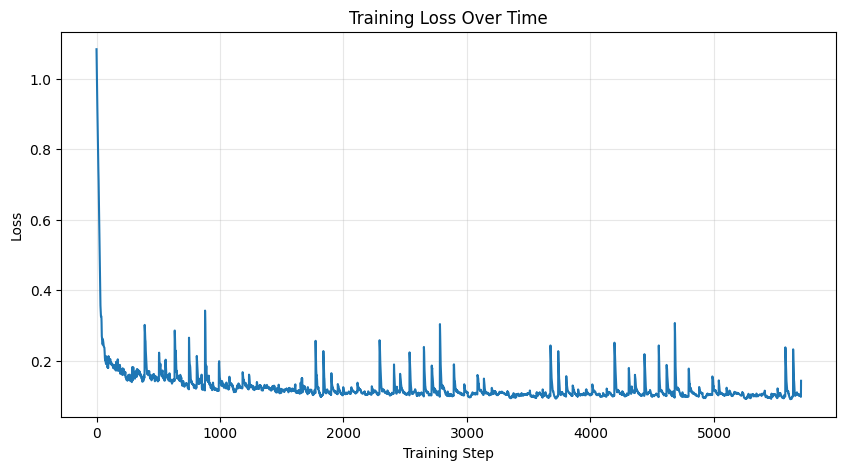


[5/6] Testing model...
Testing on 1229 time steps...


Testing: 100%|██████████| 1229/1229 [08:51<00:00,  2.31it/s]


AttributeError: 'dict' object has no attribute 'to_csv'

In [117]:
from torch.optim import Adam
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')
import traceback


def prepare_node_features(stocks, sectors, volatility, market_caps, pe_ratios, implied_vol, short_interest,
                           beta, operating_margin, return_on_equity, rsi_momentum, turnover, t):

    rows = []
    t = pd.to_datetime(t)
    if not stocks:
        return torch.empty((0, 2), dtype=torch.float32)
    for stock in stocks:
        # Get factors for stock at time t (or default values if missing)
        sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
        market_cap = market_caps.loc[t, stock] if t in market_caps.index and stock in market_caps.columns else 0.0
        pe_ratio = pe_ratios.loc[t, stock] if t in pe_ratios.index and stock in pe_ratios.columns else 0.0
        implied_volatility = implied_vol.loc[t, stock] if t in implied_vol.index and stock in implied_vol.columns else 0.0
        short_int = short_interest.loc[t, stock] if t in short_interest.index and stock in short_interest.columns else 0.0
        beta_val = beta.loc[t, stock] if t in beta.index and stock in beta.columns else 0.0
        op_margin = operating_margin.loc[t, stock] if t in operating_margin.index and stock in operating_margin.columns else 0.0
        roe = return_on_equity.loc[t, stock] if t in return_on_equity.index and stock in return_on_equity.columns else 0.0
        rsi = rsi_momentum.loc[t, stock] if t in rsi_momentum.index and stock in rsi_momentum.columns else 0.0
        turn = turnover.loc[t, stock] if t in turnover.index and stock in turnover.columns else 0.0

        # Get volatility at time t (or nearest available)
        if t in volatility.index and stock in volatility.columns:
            vol = volatility.loc[t, stock]
        else:
            # Get closest date
            available_dates = volatility.index[volatility.index <= t]
            if len(available_dates) > 0:
                closest_date = available_dates[-1]
                vol = volatility.loc[closest_date, stock]
            else:
                vol = 0.0  # Default if no data available
        rows.append([sector_id, vol, market_cap, pe_ratio, implied_volatility, short_int, beta_val, op_margin, roe, rsi, turn])
        # features is (N, 11)
        features = np.array(rows, dtype=np.float32)
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)#


        if len(features) >0:
            num_cols = features.shape[1]
            for i in range(num_cols):  # Normalize each feature to [0, 1]
                if features[:, i].max() > features[:, i].min():
                    features[:, i] = (features[:, i] - features[:, i].min()) / (features[:, i].max() - features[:, i].min() + 1e-8)

        non_zero_count = np.count_nonzero(features)
        total_elements = features.size
        zero_fraction = 1.0 - (non_zero_count / total_elements)
        
        if zero_fraction > 0.9: # If more than 90% of data is zero
            print(f"\n[WARNING] Time {t}: {zero_fraction*100:.1f}% of features are ZERO.")
            print("Sample Row (first stock):", features[0])
            # Check raw dataframe lookup for one stock to debug
            test_stock = stocks[0]
            print(f"Debug check for {test_stock} at {t}:")
            if test_stock in pe_ratios.columns:
                # Check if exact date exists
                date_exists = t in pe_ratios.index
                print(f"  - Date {t} in PE_ratios index? {date_exists}")
                if not date_exists:
                    # Show nearest dates
                    print(f"  - PE_ratios nearby dates: {pe_ratios.index[pe_ratios.index.get_indexer([t], method='nearest')]}")
                
    return torch.tensor(features, dtype=torch.float32)


def create_edge_index(num_nodes, k_neighbors=100):

    if k_neighbors is None or k_neighbors >= num_nodes - 1: # k_neighbors: Number of neighbors per node (or None for complete graph)
        # Complete graph
        edges = []
        for i in range(num_nodes):
            for j in range(num_nodes):
                if i != j:
                    edges.append([i, j])
        edge_index = torch.tensor(edges, dtype=torch.long).T # for k-nearest neighbors graph
    else:
        # k-nearest neighbors (random for now, could use correlation-based)
        edges = []
        for i in range(num_nodes):
            # Connect to k random neighbors
            neighbors = np.random.choice(
                [j for j in range(num_nodes) if j != i], 
                size=min(k_neighbors, num_nodes-1), 
                replace=False
            )
            for j in neighbors:
                edges.append([i, j])
        edge_index = torch.tensor(edges, dtype=torch.long).T
    
    return edge_index


def create_adjacency_from_correlation(corr_matrix, threshold=0.0):
    C = np.array(corr_matrix, dtype=np.float32)
    A_pos = np.maximum(C, 0.0)     
    A_neg = np.maximum(-C, 0.0)
    A_pos[A_pos < threshold] = 0 # min correlation to include edge
    A_neg[A_neg < threshold] = 0
    np.fill_diagonal(A_pos, 0) # self-loops
    np.fill_diagonal(A_neg, 0) # self-loops
    return torch.tensor(A_pos, dtype=torch.float32), torch.tensor(A_neg, dtype=torch.float32) # (N, N) is A


def train_model(model, optimizer, returns, sectors, volatility, Market_caps, PE_ratios, Implied_vol, Short_interest,
                 Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover, 
                train_dates,stock2idx, K=21, save_path='checkpoints'):
    
    device = next(model.parameters()).device
    #stocks = list(returns.columns)          # global universe order
    #stock2idx = {s: i for i, s in enumerate(stocks)}
    N_full = len(stock2idx)
    #stocks = list(returns.columns)
    #N = len(stocks)
    
    # Create edge index once (or you can recreate per timestamp)
    feature_dfs_list = [
    volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, 
    Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover
    ]

    training_losses = []
    h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state
    h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state

    print(f"Training on {len(train_dates)} time steps...")
    
    for epoch in range(3):  # Multiple passes through training data
        epoch_losses = []
        #h_prev = None  # Reset hidden state each epoch
        
        for t in tqdm(train_dates, desc=f"Epoch {epoch+1}"):
            try:
                # Get active stocks at time t
                active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
                if not active: continue
                returns_t = returns[active]
                volatility_t = volatility[active]
                market_caps_t = Market_caps[active]
                PE_ratios_t = PE_ratios[active]
                Implied_vol_t = Implied_vol[active]
                Short_interest_t = Short_interest[active]
                Beta_t = Beta[active]
                Operating_margin_t = Operating_margin[active]
                Return_on_equity_t = Return_on_equity[active]
                RSI_momentum_t = RSI_momentum[active]
                Turnover_t = Turnover[active]
                stocks_t = active
                N_t = len(stocks_t)

                edge_index = create_edge_index(N_t, k_neighbors=15)
                # 1. Compute PCA embeddings from returns
                node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K)
                
                # Extract embeddings for all stocks
                H_list = []
                for stock in stocks_t:
                    if stock in node_embeddings:
                        emb = node_embeddings[stock]
                        if len(emb.shape) > 1 and emb.shape[0] == 1:
                            H_list.append(emb[0])  # Take first embedding
                        else:
                            H_list.append(emb)
                        #H_list.append(node_embeddings[stock][0])  # Take first embedding
                    else:
                        # Default embedding
                        H_list.append(np.zeros(10))  # Assuming L=10
                
                H_t = torch.tensor(np.array(H_list), dtype=torch.float32)
                
                # 2. Compute correlation matrix
                corr_matrix, _ = correlation_matrix(returns_t, t, K)
                corr_t = torch.tensor(corr_matrix, dtype=torch.float32)
                
                # 3. Prepare node features [sector, volatility]
                X_t = prepare_node_features(stocks_t, sectors, volatility_t, market_caps_t, PE_ratios_t, Implied_vol_t, Short_interest_t, Beta_t, Operating_margin_t, Return_on_equity_t, RSI_momentum_t, Turnover_t, t)
                
                #if np.isnan(corr_matrix).any():
                #    print("NaNs in corr:", np.isnan(corr_matrix).sum())

                # 4. Create adjacency matrix for reconstruction (optional)
                A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix, threshold=0.0)
                A_t_pos = A_t_pos.to(device)
                A_t_neg = A_t_neg.to(device)

                active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
                h_prev_pos = h_prev_pos_full.index_select(0, active_idx) 
                h_prev_neg = h_prev_neg_full.index_select(0, active_idx) 
                # 5. Training step
                # loss, h_prev_pos,h_prev_neg, signals = train_step(
                #     model, optimizer, X_t, H_t, edge_index, 
                #     corr_matrix_tensor, A_t_pos,A_t_neg, h_prev_pos, h_prev_neg
                # )
                model.train()
                optimizer.zero_grad()
                h_t_pos, h_t_neg, signals, loss, A_pos, A_neg = model(
                    X_t, H_t, edge_index, corr_t, 
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg, 
                    A_t_pos=A_t_pos, A_t_neg=A_t_neg
                )
                loss.backward()
                optimizer.step()

                if np.isnan(loss.item()):
                    print(f"!!! NaN Loss detected at time {t} !!!")
                    print("Active stocks:", len(active))
                    print("X_t range:", X_t.min().item(), X_t.max().item())
                    break
                # Update full hidden states
                h_prev_pos_full[active_idx] = h_t_pos.detach()
                h_prev_neg_full[active_idx] = h_t_neg.detach()

                epoch_losses.append(loss.item())
                
            except Exception as e:
                print(f"Error at time {t}: {str(e)}")
                continue
        
        avg_loss = np.mean(epoch_losses)
        training_losses.extend(epoch_losses)
        print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")
        
        # Save checkpoint
        if save_path is not None:
            # Create directory if it doesn't exist
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, save_path.replace('.pt', f'_epoch{epoch}.pt'))
    
    return training_losses


def test_model(model, returns, sectors, volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta, 
               Operating_margin, Return_on_equity, RSI_momentum, Turnover, test_dates, stock2idx, K=21):
    device = next(model.parameters()).device
    #stocks = list(returns.columns)
    N_full = len(stock2idx)
    
    h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, device=device)
    h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, device=device)

    feature_dfs_list = [
        volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, 
        Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover
    ]
    # Storage for results
    all_signals = []
    valid_dates = []
    active_lists = []

    print(f"Testing on {len(test_dates)} time steps...")
    
    for t in tqdm(test_dates, desc="Testing"):
        try:
            # 1. Compute PCA embeddings
            active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
            #active_idx = torch.tensor([stock2idx[s] for s in active], dtype=torch.long)
            if not active:
                continue

            returns_t = returns[active]
            volatility_t = volatility[active] 
            market_caps_t = Market_caps[active]
            PE_ratios_t = PE_ratios[active]
            Implied_vol_t = Implied_vol[active]
            Short_interest_t = Short_interest[active]
            Beta_t = Beta[active]
            Operating_margin_t = Operating_margin[active]
            Return_on_equity_t = Return_on_equity[active]
            RSI_momentum_t = RSI_momentum[active]
            Turnover_t = Turnover[active]
            stocks_t    = active
            N_t         = len(stocks_t)

            # Create edge index
            edge_index = create_edge_index(N_t, k_neighbors=5)
            
            node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K)
            
            H_list = []
            for stock in stocks_t:
                if stock in node_embeddings.keys():
                    H_list.append(node_embeddings[stock]) 
                else:
                    H_list.append(np.zeros(10))

            H_t = torch.tensor(np.array(H_list), dtype=torch.float32)
            
            # 2. Correlation matrix
            corr_matrix, _ = correlation_matrix(returns_t, t, K)
            corr_t = torch.tensor(corr_matrix, dtype=torch.float32)
            
            # 3. Node features
            X_t = prepare_node_features(stocks_t, sectors, volatility_t, market_caps_t, PE_ratios_t, Implied_vol_t, Short_interest_t, Beta_t, Operating_margin_t, Return_on_equity_t, RSI_momentum_t, Turnover_t, t)
            
            # 4. Inference
            # h_prev_pos, h_prev_neg, signals, A_pos, A_neg = inference_step(
            #     model, X_t, H_t, edge_index, corr_matrix_tensor, h_prev_pos, h_prev_neg
            # )
            active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
            h_prev_pos = h_prev_pos_full.index_select(0, active_idx) 
            h_prev_neg = h_prev_neg_full.index_select(0, active_idx) 

            with torch.no_grad():
                h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
                    X_t, H_t, edge_index, corr_t,
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg,
                    A_t_pos=None, A_t_neg=None
                )

            h_prev_pos_full[active_idx] = h_t_pos.detach()
            h_prev_neg_full[active_idx] = h_t_neg.detach()
            
            all_signals.append(signals.cpu().numpy())
            valid_dates.append(t)
            active_lists.append(stocks_t)
            
        except Exception as e:
            # FIX: Print the ACTUAL error to debug
            print(f"\n!!! Error at {t} !!!")
            traceback.print_exc() 
            continue
        # except Exception as e:
        #     raise RuntimeError(f"Test failed at time {t}") from e
    
    # # Create results DataFrame
    # signals_array = np.array(all_signals)  # (T, N)
    # results = pd.DataFrame(
    #     signals_array,
    #     index=valid_dates,
    #     columns=stocks
    # )
    results = {d: (active_lists[i], all_signals[i]) for i, d in enumerate(valid_dates)}
    return results
    
    #return results

def visualize_results(results, prices, title="Bubble Signals Over Time"):

    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Plot 1: Average bubble signal over time
    avg_signal = results.mean(axis=1)
    axes[0].plot(avg_signal.index, avg_signal.values, linewidth=2, color='red')
    axes[0].fill_between(avg_signal.index, 0, avg_signal.values, alpha=0.3, color='red')
    axes[0].set_ylabel('Average Bubble Signal', fontsize=12)
    axes[0].set_title(f'{title} - Market-Wide Signal', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3)
    axes[0].axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
    axes[0].legend()
    
    # Plot 2: Top 5 stocks with highest average bubble signal
    top_stocks = results.mean(axis=0).nlargest(5)
    for stock in top_stocks.index:
        axes[1].plot(results.index, results[stock], label=stock, linewidth=2)
    axes[1].set_ylabel('Bubble Signal', fontsize=12)
    axes[1].set_title('Top 5 Stocks with Highest Bubble Signals', fontsize=14, fontweight='bold')
    axes[1].legend(loc='upper left')
    axes[1].grid(alpha=0.3)
    
    # Plot 3: Heatmap of bubble signals
    # Sample every few dates for visibility
    sample_freq = max(1, len(results) // 50)
    sampled_results = results.iloc[::sample_freq]
    
    im = axes[2].imshow(sampled_results.T, aspect='auto', cmap='YlOrRd', 
                        interpolation='nearest')
    axes[2].set_ylabel('Stocks', fontsize=12)
    axes[2].set_xlabel('Time', fontsize=12)
    axes[2].set_title('Bubble Signal Heatmap Across All Stocks', fontsize=14, fontweight='bold')
    
    # Set x-axis labels
    x_positions = np.arange(0, len(sampled_results), max(1, len(sampled_results) // 10))
    x_labels = [sampled_results.index[i].strftime('%Y-%m-%d') for i in x_positions]
    axes[2].set_xticks(x_positions)
    axes[2].set_xticklabels(x_labels, rotation=45, ha='right')
    
    plt.colorbar(im, ax=axes[2], label='Bubble Signal')
    
    plt.tight_layout()
    return fig

def main():
    
    # prep data
    print("\n[1/6] Loading data...")
    device = torch.device("cpu")
    
    # Load prices
    prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    prices.dropna(how='all', inplace=True)
    prices = prices.ffill().bfill()
    prices.columns = prices.columns.droplevel(1)
    
    all_stocks = prices.columns.tolist()
    stock2idx = {s: i for i, s in enumerate(all_stocks)}
    idx2stock = {i: s for s, i in stock2idx.items()}
    N_full = len(all_stocks)

    # Load sectors
    sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                            header=0, index_col=0)
    sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes
    

    tickers = prices.columns.get_level_values(0).unique().tolist()
    node_map = {ticker: i for i, ticker in enumerate(tickers)}
    
    # Split data: Train 2007-2009, Test 2019-2021
    train_prices = prices.loc['2012-01-01':'2019-12-31']
    test_prices = prices.loc['2020-01-01':'2024-12-31']

    returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    returns.columns = returns.columns.get_level_values(0)
    returns.dropna(how='all', inplace=True) 
    returns = returns.pct_change().dropna(how='all')
    returns = returns.ffill().bfill()
    # Compute returns
    # train_returns = train_prices.pct_change().dropna(how='all')
    # test_returns = test_prices.pct_change().dropna(how='all')
    train_returns = returns.loc['2012-01-01':'2019-12-31']
    test_returns = returns.loc['2020-01-01':'2024-12-31']
    
    # Compute volatility
    train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
    test_volatility = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)

    # Helper to load and fix dates
    def load_and_fix_index(filename):
        df = pd.read_csv(filename, index_col=0)
        df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
        df.dropna(how='all', inplace=True)
        df = df.ffill().bfill()
        return df

    # Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
    Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

    PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

    Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

    Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
    Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
    Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
    RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
    Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
    Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')

    
    print(f"Training period: {train_returns.index[0]} to {train_returns.index[-1]}")
    print(f"Testing period: {test_returns.index[0]} to {test_returns.index[-1]}")
    print(f"Number of stocks: {len(train_returns.columns)}")
    
    # prep trainig and testing dates
    print("\n[2/6] Preparing training dates...")
    
    K = 21  # Window size
    min_date = train_returns.index[0] + pd.Timedelta(days=K*2)
    train_dates = train_returns.loc[min_date:].index
    
    test_min_date = test_returns.index[0] + pd.Timedelta(days=K*2)
    test_dates = test_returns.loc[test_min_date:].index
    
    print(f"Training time steps: {len(train_dates)}")
    print(f"Testing time steps: {len(test_dates)}")
    
    # initialize model
    print("\n[3/6] Initializing model...")
    
    # Model hyperparameters
    N = len(train_returns.columns)  # Number of stocks
    feature_dim = 11  # [sector_id, volatility, market caps, PE, Implied_vol, ShortInterestPct, Beta, OpMargin, ROE, RSI, Turnover] TODO: try adding more features
    embedding_dim = 10  # PCA embedding dimension (L)
    
    gat_config = {
        'num_layers': 1,
        'heads': [1],  # Single attention head
        'features': [embedding_dim, 8]  # Input: L=10, Output: 8
    }
    
    model = BubbleDetectionModel(
        gat_config=gat_config,
        feature_dim=feature_dim,
        embedding_dim=embedding_dim,
        encoder_channels=[16, 8],  # Spatial encoder: 2 -> 16 -> 8
        hidden_dim=32,  # GRU hidden dimension
        num_diffusion_steps=1,
        use_structure_recon=True,
        dropout=0.1
    )
    
    optimizer = Adam(model.parameters(), lr=0.001)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    # training
    print("\n[4/6] Training model...")
    
    # Create output directory
    os.makedirs('outputs', exist_ok=True)
    
    training_losses = train_model(
        model, optimizer, train_returns, sectors, train_volatility, Market_caps, PE_ratios, Implied_vol,
        Short_interest, Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover,
        train_dates, stock2idx, K=K, save_path='outputs/bubble_model.pt'
    )
    
    # Plot training loss
    plt.figure(figsize=(10, 5))
    plt.plot(training_losses)
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Time')
    plt.grid(alpha=0.3)
    plt.savefig('outputs/training_loss.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # testing
    print("\n[5/6] Testing model...")
    
    test_results = test_model(model, test_returns, sectors, test_volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta, 
               Operating_margin, Return_on_equity, RSI_momentum, Turnover, test_dates, stock2idx, K=21)
    
    #print(f"Average bubble signal: {test_results.mean().mean():.4f}")
    #print(f"Max bubble signal: {test_results.max().max():.4f}")

    # Save results
    test_results.to_csv('outputs/bubble_signals_test.csv')
    print("Results saved to 'outputs/bubble_signals_test.csv'")


    print("\n[6/6] Visualizing results...")

    fig = visualize_results(test_results, test_prices, 
                            title="Bubble Detection Signals (2019-2021)")
    plt.savefig('outputs/bubble_signals_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Summary statistics

    print(f"Mean signal across all stocks and time: {test_results.mean().mean():.4f}")
    print(f"Std signal: {test_results.std().std():.4f}")
    print(f"\nTop 10 stocks with highest average bubble signal:")
    print(test_results.mean(axis=0).nlargest(10))

    print(f"\nTop 10 dates with highest average bubble signal:")
    print(test_results.mean(axis=1).nlargest(10))

    # Identify potential bubble periods (signal > 0.7)
    high_signal_dates = test_results.mean(axis=1)[test_results.mean(axis=1) > 0.7]
    if len(high_signal_dates) > 0:
        print(f"\n⚠️  High bubble risk periods detected ({len(high_signal_dates)} dates):")
        print(high_signal_dates)

    
if __name__ == "__main__":
    main()

In [118]:
%debug

> c:\users\archi\appdata\local\temp\ipykernel_8732\922867575.py(541)main()



In [119]:
print(len(recovered_results))

1175


Converting dictionary to DataFrame...
Successfully saved to 'outputs/bubble_signals_test.csv'
Data shape: (1175, 497)


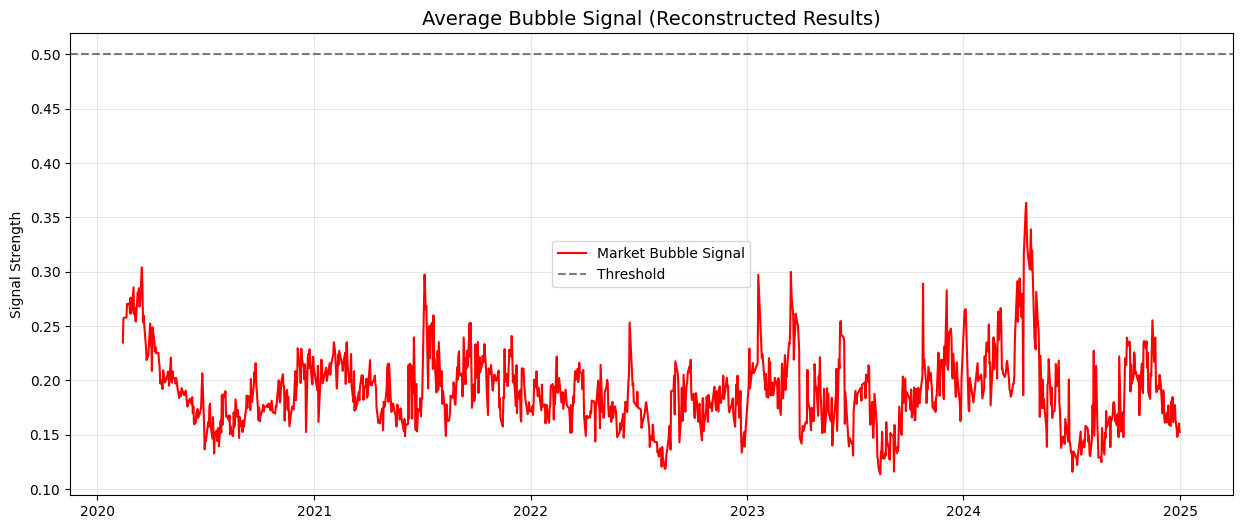

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def process_results_to_dataframe(results_dict):
    """
    Converts the dictionary {date: ([stocks], [signals])} 
    into a pandas DataFrame where Columns=Stocks, Index=Date.
    """
    print("Converting dictionary to DataFrame...")
    rows_list = []
    
    for date, (stocks, signals) in results_dict.items():
        # Ensure signals are a flat list
        if hasattr(signals, 'flatten'):
            signals = signals.flatten()
        elif isinstance(signals, list):
            signals = np.array(signals).flatten()
            
        # Create a dictionary for this row: {'Date': 2021-01-01, 'AAPL': 0.5, ...}
        # zip pairs each stock with its signal
        row = dict(zip(stocks, signals))
        row['Date'] = date
        rows_list.append(row)
    
    # Create DataFrame (Pandas automatically aligns columns and handles missing stocks with NaN)
    df = pd.DataFrame(rows_list)
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    return df

# --- 1. Convert ---
df_results = process_results_to_dataframe(recovered_results)

# --- 2. Save ---
df_results.to_csv('outputs/bubble_signals_test.csv')
print("Successfully saved to 'outputs/bubble_signals_test.csv'")

# --- 3. Visualize ---
print(f"Data shape: {df_results.shape}")

# Calculate Market Average Signal
avg_signal = df_results.mean(axis=1)

plt.figure(figsize=(15, 6))
plt.plot(avg_signal.index, avg_signal.values, color='red', label='Market Bubble Signal')
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
plt.title('Average Bubble Signal (Reconstructed Results)', fontsize=14)
plt.ylabel('Signal Strength')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

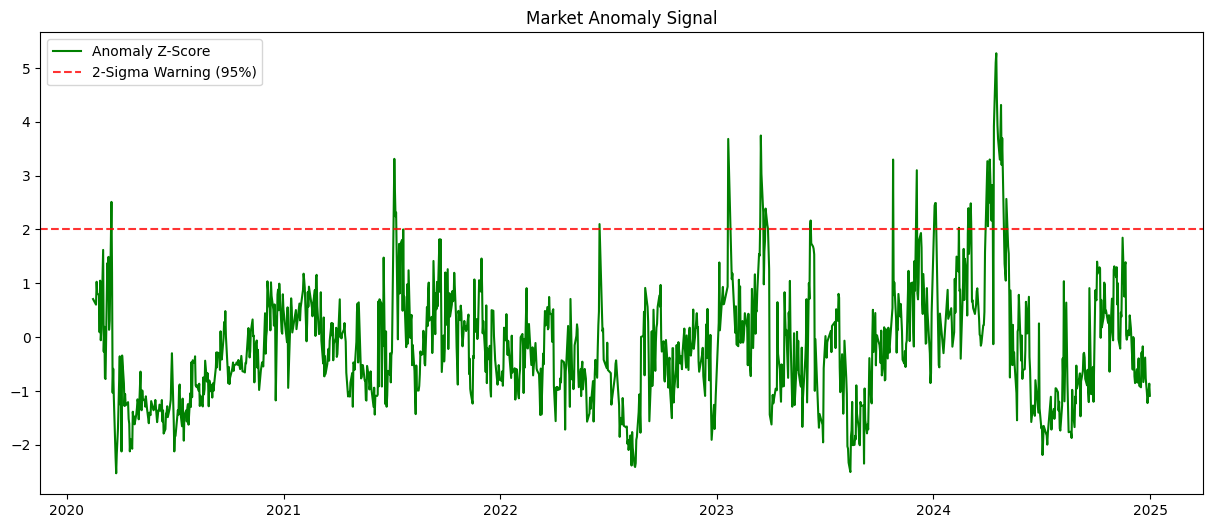

In [129]:
# Use an expanding window (starts with min_periods=1)
# This calculates the mean using "all data available so far"
expanding_mean = df_results.mean(axis=1).expanding(min_periods=1).mean()
expanding_std = df_results.mean(axis=1).expanding(min_periods=1).std()

# Recalculate Z-Score
z_score_expanding = (df_results.mean(axis=1) - expanding_mean) / expanding_std

# Plot again
plt.figure(figsize=(15, 6))
plt.plot(z_score_expanding.index, z_score_expanding.values, color='green', label='Anomaly Z-Score')
plt.axhline(y=2.0, color='red', linestyle='--', alpha=0.8, label='2-Sigma Warning (95%)')
plt.title('Market Anomaly Signal')
plt.legend()
plt.show()

[1/3] Loading Data and Model...
Loading weights from outputs/bubble_model_epoch2.pt...
[2/3] Collecting Graph History...


Generating Snapshots: 100%|██████████| 39/39 [00:06<00:00,  6.49it/s]


[3/3] Creating Animation...
Initializing Animation (29 frames)...
Animation saved to outputs/market_structure.gif


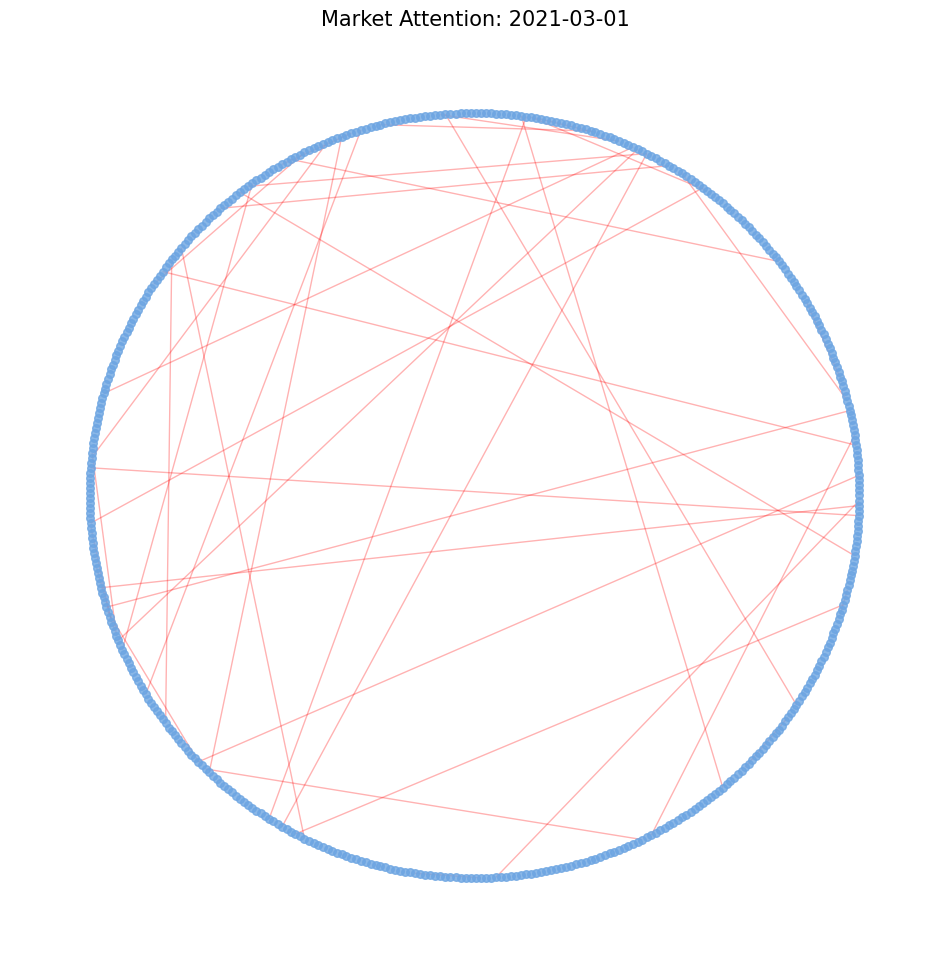

In [ ]:
import torch
import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm

# ==========================================
# 1. LOAD DATA & MODEL (The Setup)
# ==========================================
print("[1/3] Loading Data and Model...")

# 1. Load Data
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)

sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes

# Calculate Derived Data
returns = prices.pct_change().dropna(how='all')
volatility = returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
all_stocks = returns.columns.tolist()
stock2idx = {s: i for i, s in enumerate(all_stocks)}

# 2. Initialize Model Architecture
embedding_dim = 10
gat_config = {'num_layers': 1, 'heads': [1], 'features': [embedding_dim, 8]}

model = BubbleDetectionModel(
    gat_config=gat_config,
    feature_dim=2,
    embedding_dim=embedding_dim,
    encoder_channels=[16, 8],
    hidden_dim=32,
    num_diffusion_steps=1,
    use_structure_recon=True,
    dropout=0.1
)

# 3. Load Trained Weights
checkpoint_path = 'outputs/bubble_model_epoch2.pt'  # Loading the last epoch
if os.path.exists(checkpoint_path):
    print(f"Loading weights from {checkpoint_path}...")
    
    # --- FIX IS HERE: weights_only=False ---
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval() 
else:
    raise FileNotFoundError(f"Could not find {checkpoint_path}. Did you run training?")

# ==========================================
# 2. ANIMATION FUNCTIONS
# ==========================================

def collect_graph_history(model, returns, sectors, volatility, start_date, end_date, stock2idx, K=21):
    device = next(model.parameters()).device
    all_dates = returns.index
    mask = (all_dates >= start_date) & (all_dates <= end_date)
    target_dates = all_dates[mask]
    
    print(f"Collecting graph snapshots for {len(target_dates)} days...")
    history = []
    
    N_full = len(stock2idx)
    h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, device=device)
    h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, device=device)
    
    for t in tqdm(target_dates, desc="Generating Snapshots"):
        try:
            active = get_active_stocks(returns, t, lookback_days=int(K*1.5), min_obs=K)
            if not active or len(active) < 2: continue

            returns_t = returns[active]
            volatility_t = volatility[active]
            stocks_t = active
            N_t = len(stocks_t)
            
            # Embeddings (Using the clean/robust version logic)
            node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K)
            H_list = []
            for stock in stocks_t:
                if stock in node_embeddings:
                    emb = node_embeddings[stock]
                    # Ensure flattening happens if it's nested
                    emb = np.array(emb).flatten()
                    # Ensure size 10
                    if len(emb) != 10: emb = np.zeros(10)
                    H_list.append(emb)
                else:
                    H_list.append(np.zeros(10))
            
            H_t = torch.tensor(np.stack(H_list), dtype=torch.float32).to(device)
            H_t = torch.nan_to_num(H_t, nan=0.0)

            # Rest of inputs
            corr_matrix, _ = correlation_matrix(returns_t, t, K)
            corr_t = torch.tensor(np.nan_to_num(corr_matrix), dtype=torch.float32).to(device)
            X_t = prepare_node_features(stocks_t, sectors, volatility_t, t).to(device)
            X_t = torch.nan_to_num(X_t, nan=0.0)
            
            edge_index = create_edge_index(N_t, k_neighbors=5).to(device)
            active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
            
            h_prev_pos = h_prev_pos_full.index_select(0, active_idx)
            h_prev_neg = h_prev_neg_full.index_select(0, active_idx)

            with torch.no_grad():
                h_t_pos, h_t_neg, _, _, A_pos, _ = model(
                    X_t, H_t, edge_index, corr_t,
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg,
                    A_t_pos=None, A_t_neg=None
                )
            
            history.append({
                'date': t,
                'stocks': stocks_t,
                'adj': A_pos.cpu().numpy()
            })
            
            h_prev_pos_full[active_idx] = h_t_pos.detach()
            h_prev_neg_full[active_idx] = h_t_neg.detach()
            
        except Exception as e:
            continue
            
    return history

def animate_network(history, save_filename='outputs/market_structure.gif'):
    if not history:
        print("No history collected!")
        return

    print(f"Initializing Animation ({len(history)} frames)...")
    
    # 1. Setup Layout
    all_stocks = set()
    for snap in history: all_stocks.update(snap['stocks'])
    all_stocks_list = sorted(list(all_stocks))
    
    # Pre-compute layout positions
    G_super = nx.Graph()
    G_super.add_nodes_from(all_stocks_list)
    # Using shell layout puts nodes in circles, good for connectivity
    pos = nx.circular_layout(G_super) 
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    def update(frame_idx):
        ax.clear()
        snapshot = history[frame_idx]
        
        G = nx.Graph()
        G.add_nodes_from(snapshot['stocks'])
        
        # Thresholding edges
        adj = snapshot['adj']
        flat = adj.flatten()
        flat = flat[flat > 0]
        if len(flat) > 0:
            # Draw only top 2% strongest edges
            threshold = np.percentile(flat, 98) 
            rows, cols = np.where(adj >= threshold)
            for r, c in zip(rows, cols):
                if r != c:
                    G.add_edge(snapshot['stocks'][r], snapshot['stocks'][c], weight=adj[r,c])

        # Draw
        current_pos = {k: pos[k] for k in snapshot['stocks'] if k in pos}
        
        # Draw Nodes
        nx.draw_networkx_nodes(G, current_pos, node_size=30, node_color='#6DA5E2', ax=ax, alpha=0.8)
        
        # Draw Edges
        if G.number_of_edges() > 0:
            nx.draw_networkx_edges(G, current_pos, edge_color='red', alpha=0.3, ax=ax)
            
        ax.set_title(f"Market Attention: {snapshot['date'].strftime('%Y-%m-%d')}", fontsize=15)
        ax.axis('off')

    ani = animation.FuncAnimation(fig, update, frames=len(history), interval=200)
    
    os.makedirs('outputs', exist_ok=True)
    try:
        # Fallback to Pillow (GIF) if FFmpeg isn't installed
        ani.save(save_filename, writer='pillow', fps=5)
        print(f"Animation saved to {save_filename}")
    except Exception as e:
        print(f"Could not save animation: {e}")
    plt.show()

# ==========================================
# 3. RUN IT
# ==========================================
print("[2/3] Collecting Graph History...")
history = collect_graph_history(
    model, returns, sectors, volatility, 
    start_date=pd.Timestamp("2021-01-01"), 
    end_date=pd.Timestamp("2021-03-01"), 
    stock2idx=stock2idx, 
    K=21
)

if len(history) > 0:
    print("[3/3] Creating Animation...")
    animate_network(history)
else:
    print("No history collected. Check dates/data.")

In [ ]:
import torch
import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import traceback

# ==========================================
# 1. ROBUST HELPER FUNCTIONS (The Fixes)
# ==========================================

def compute_initial_node_embeddings(returns, t, K, eps=0.0, active=None): 
    # This version ensures embeddings are simple 1D arrays of shape (10,)
    node_embeddings = {}
    t = pd.to_datetime(t)
    
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all') 
    if windowed_returns.empty: return {}, []
    
    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        valid_active = [c for c in active if c in window.columns]
        if not valid_active: return {}, []
        window = window[valid_active]
        
    if window.shape[0] < 2 or window.shape[1] == 0: return {}, []

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]

    active_cols = window.columns.tolist()
    if not active_cols: return {}, []

    try:
        U, S, Vt = np.linalg.svd(window.values, full_matrices=False) 
        V = Vt.T
        H = V @ np.diag(S) 
    except:
        return {}, []
    
    target_dim = 10
    if H.shape[1] > target_dim:
        H = H[:, :target_dim]
    elif H.shape[1] < target_dim:
        padding = np.zeros((H.shape[0], target_dim - H.shape[1]))
        H = np.hstack([H, padding])

    scaler = MinMaxScaler(feature_range=(0, 1))
    H = scaler.fit_transform(H) 

    # FIX: Store exactly as (10,) array, no lists, no nesting
    for i, stock in enumerate(active_cols): 
        node_embeddings[stock] = H[i, :] 
        
    return node_embeddings, active_cols

def collect_graph_history(model, returns, sectors, volatility, start_date, end_date, stock2idx, K=21):
    device = next(model.parameters()).device
    all_dates = returns.index
    mask = (all_dates >= start_date) & (all_dates <= end_date)
    target_dates = all_dates[mask]
    
    print(f"Collecting graph snapshots for {len(target_dates)} days...")
    history = []
    
    N_full = len(stock2idx)
    h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, device=device)
    h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, device=device)
    
    for t in tqdm(target_dates, desc="Generating Snapshots"):
        try:
            active = get_active_stocks(returns, t, lookback_days=int(K*1.5), min_obs=K)
            if not active or len(active) < 2: continue

            returns_t = returns[active]
            volatility_t = volatility[active]
            stocks_t = active
            N_t = len(stocks_t)
            
            # 1. Embeddings (With Shape Fix)
            node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K)
            
            H_list = []
            for stock in stocks_t:
                if stock in node_embeddings:
                    emb = node_embeddings[stock]
                    # SAFETY: Flatten to ensures shape is (10,)
                    emb = np.array(emb).flatten()
                    if emb.shape[0] != 10: 
                        emb = np.zeros(10)
                    H_list.append(emb)
                else:
                    H_list.append(np.zeros(10))
            
            # Stack to create (N, 10)
            H_t_np = np.stack(H_list).astype(np.float32)
            H_t = torch.tensor(H_t_np).to(device)
            H_t = torch.nan_to_num(H_t, nan=0.0)

            # 2. Inputs
            corr_matrix, _ = correlation_matrix(returns_t, t, K)
            corr_t = torch.tensor(np.nan_to_num(corr_matrix), dtype=torch.float32).to(device)
            
            X_t = prepare_node_features(stocks_t, sectors, volatility_t, t).to(device)
            X_t = torch.nan_to_num(X_t, nan=0.0)
            
            edge_index = create_edge_index(N_t, k_neighbors=5).to(device)
            active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
            
            h_prev_pos = h_prev_pos_full.index_select(0, active_idx)
            h_prev_neg = h_prev_neg_full.index_select(0, active_idx)

            # 3. Forward Pass
            with torch.no_grad():
                h_t_pos, h_t_neg, _, _, A_pos, _ = model(
                    X_t, H_t, edge_index, corr_t,
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg,
                    A_t_pos=None, A_t_neg=None
                )
            
            # Save Snapshot
            history.append({
                'date': t,
                'stocks': stocks_t,
                'adj': A_pos.cpu().numpy()
            })
            
            # Update Hidden
            h_prev_pos_full[active_idx] = h_t_pos.detach()
            h_prev_neg_full[active_idx] = h_t_neg.detach()
            
        except Exception as e:
            # print(f"Skipping {t}: {e}")
            continue
            
    return history

def animate_network(history, save_filename='outputs/market_structure.gif'):
    if not history:
        print("No history collected!")
        return

    print(f"Initializing Animation ({len(history)} frames)...")
    
    # 1. Setup Fixed Layout
    all_stocks = set()
    for snap in history: all_stocks.update(snap['stocks'])
    all_stocks_list = sorted(list(all_stocks))
    
    G_super = nx.Graph()
    G_super.add_nodes_from(all_stocks_list)
    pos = nx.circular_layout(G_super) 
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    def update(frame_idx):
        ax.clear()
        snapshot = history[frame_idx]
        
        G = nx.Graph()
        G.add_nodes_from(snapshot['stocks'])
        
        # 2. Add Weighted Edges
        adj = snapshot['adj']
        flat = adj.flatten()
        flat = flat[flat > 0]
        
        if len(flat) > 0:
            # Dynamic Threshold (Top 2%)
            threshold = np.percentile(flat, 98) 
            rows, cols = np.where(adj >= threshold)
            
            for r, c in zip(rows, cols):
                if r != c:
                    G.add_edge(snapshot['stocks'][r], snapshot['stocks'][c], weight=adj[r,c])

        # 3. Draw Nodes
        current_pos = {k: pos[k] for k in snapshot['stocks'] if k in pos}
        nx.draw_networkx_nodes(G, current_pos, node_size=30, node_color='#6DA5E2', ax=ax, alpha=0.8)
        
        # 4. Draw Edges with Variable Thickness
        if G.number_of_edges() > 0:
            edges = G.edges()
            weights = [G[u][v]['weight'] for u, v in edges]
            
            # Normalize thickness (Max thickness = 3.0)
            max_w = max(weights) if weights else 1.0
            widths = [(w / max_w) * 3.0 for w in weights]
            
            nx.draw_networkx_edges(
                G, current_pos, 
                width=widths, 
                edge_color='red', 
                alpha=0.4, 
                ax=ax
            )
            
        ax.set_title(f"Market Attention: {snapshot['date'].strftime('%Y-%m-%d')}", fontsize=15)
        ax.axis('off')

    ani = animation.FuncAnimation(fig, update, frames=len(history), interval=200)
    
    os.makedirs('outputs', exist_ok=True)
    try:
        # Saving using Pillow (GIF)
        ani.save(save_filename, writer='pillow', fps=5)
        print(f"Animation saved to {save_filename}")
    except Exception as e:
        print(f"Could not save animation: {e}")
    plt.show()

# ==========================================
# 2. LOAD DATA & MODEL 
# ==========================================
print("[1/3] Loading Data and Model...")

# Load Data (Assuming files exist in folder)
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)

sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes

returns = prices.pct_change().dropna(how='all')
volatility = returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
all_stocks = returns.columns.tolist()
stock2idx = {s: i for i, s in enumerate(all_stocks)}

# Init Model
embedding_dim = 10
gat_config = {'num_layers': 1, 'heads': [1], 'features': [embedding_dim, 8]}

model = BubbleDetectionModel(
    gat_config=gat_config,
    feature_dim=2,
    embedding_dim=embedding_dim,
    encoder_channels=[16, 8],
    hidden_dim=32,
    num_diffusion_steps=1,
    use_structure_recon=True,
    dropout=0.1
)

# Load Weights (Safely)
checkpoint_path = 'outputs/bubble_model_epoch2.pt'
if os.path.exists(checkpoint_path):
    print(f"Loading weights from {checkpoint_path}...")
    # FIX: weights_only=False to allow numpy scalars
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
else:
    raise FileNotFoundError(f"Missing {checkpoint_path}. Please train the model first.")

# ==========================================
# 3. EXECUTE ANIMATION
# ==========================================
print("[2/3] Collecting Graph History...")

# Define Period (e.g., GME Squeeze)
history = collect_graph_history(
    model, returns, sectors, volatility, 
    start_date=pd.Timestamp("2007-06-01"), 
    end_date=pd.Timestamp("2008-01-01"), 
    stock2idx=stock2idx, 
    K=21
)

if len(history) > 0:
    print("[3/3] Creating Animation...")
    animate_network(history, save_filename='outputs/market_structure_weighted_2008.gif')
else:
    print("No history collected. Check dates.")

[1/3] Loading Data and Model...


NameError: name 'BubbleDetectionModel' is not defined